<a href="https://colab.research.google.com/github/sparshgoyal2701/Indo-Floods-Data-Visualization-Project-/blob/Projects/Flood_Events_in_India.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction
The INDOFLOODS database is an extensive flood event database designed to support flood research and management in India. It integrates long-term station discharge observations with official flooding thresholds to provide detailed historical flood event information, covering multiple flood events across various catchments in India, excluding the Ganga and Brahmaputra basins (authors: Kuntla, Sai Kiran and Saharia, Manabendra, 2025).

## Database Content and Structure
The database includes key hydrological data on floods:
- Start and end date and time of flooding
- Peak flood water level with dates
- Peak discharge with dates
- Flood volume and event duration
- Time to peak and recession time

In addition to flooding details, metadata such as upstream catchment area, geographic coordinates, and river and tributary names are included. The database has been enhanced with catchment-scale attributes:
- Geomorphological
- Climatological
- Event-scale precipitation
- Land cover
- Soil characteristics
- Lithology
- Anthropogenic characteristics



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df=pd.read_csv("/content/drive/MyDrive/PROJECTS/Datavisualization /Flood Events in India/metadata_indofloods.csv")
df.head()

,GaugeID,Warning Level,Danger Level,Station,Latitude,Longitude,River Name/ Tributory/ SubTributory,Basin,State,Start_date,End_date,Level_Entries,Streamflow_Entries,Privacy,Source Catchment Area,Catchment Area,Area variation (%),Reliability
0,INDOFLOODS-gauge-394,259.20,262.00,Biligundulu,12.1800,77.7300,Cauvery,Cauvery,Karnataka,1971-08-30,2020-05-27,17715,17273,Open,36682.0,36889.800780,0.566493,Safe
1,INDOFLOODS-gauge-118,66.75,67.75,Jainagar,26.5833,86.1481,Ganga/Kosi/ Kamla-Balan,Ganga - Brahmaputra - Meghna/Barak,Bihar,1970-07-01,2010-12-31,14134,13725,Restricted,2131.0,2118.569336,0.583325,Safe
2,INDOFLOODS-gauge-119,49.00,50.00,Jhanjharpur,26.2333,86.2594,Ganga/Kosi/ Kamla-Balan,Ganga - Brahmaputra - Meghna/Barak,Bihar,1970-01-01,2010-12-31,14939,14616,Restricted,2945.0,3504.423584,18.995707,Safe
3,INDOFLOODS-gauge-121,70.00,71.00,DHENG BRIDGE,26.7228,85.3231,Ganga/Kosi/ Bagmati,Ganga - Brahmaputra - Meghna/Barak,Bihar,1970-07-01,2010-12-31,14762,14750,Restricted,3790.0,3580.846924,5.518551,Safe
4,INDOFLOODS-gauge-560,218.00,220.98,Burhanpur,21.2994,76.2350,Tapi,Tapi,Madhya Pradesh,1972-09-14,2019-08-20,16611,16249,Open,8487.0,8926.981445,5.184181,Safe


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   GaugeID                              214 non-null    object 
 1   Warning Level                        214 non-null    float64
 2   Danger Level                         212 non-null    float64
 3   Station                              214 non-null    object 
 4   Latitude                             214 non-null    float64
 5   Longitude                            214 non-null    float64
 6   River Name/ Tributory/ SubTributory  214 non-null    object 
 7   Basin                                212 non-null    object 
 8   State                                214 non-null    object 
 9   Start_date                           214 non-null    object 
 10  End_date                             214 non-null    object 
 11  Level_Entries                   

**Reasoning**:
Convert 'Start_date' and 'End_date' columns to datetime objects and display the updated DataFrame info.



In [5]:
df['Start_date'] = pd.to_datetime(df['Start_date'], format='%Y-%m-%d')
df['End_date'] = pd.to_datetime(df['End_date'], format='%Y-%m-%d')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   GaugeID                              214 non-null    object        
 1   Warning Level                        214 non-null    float64       
 2   Danger Level                         212 non-null    float64       
 3   Station                              214 non-null    object        
 4   Latitude                             214 non-null    float64       
 5   Longitude                            214 non-null    float64       
 6   River Name/ Tributory/ SubTributory  214 non-null    object        
 7   Basin                                212 non-null    object        
 8   State                                214 non-null    object        
 9   Start_date                           214 non-null    datetime64[ns]
 10  End_date      

**Reasoning**:
Extract the start and end years from the datetime columns and display the new columns.



In [6]:
df["Start_Year"] = df['Start_date'].dt.year
df["End_Year"] = df['End_date'].dt.year
display(df[["Start_Year",'End_Year']])

,Start_Year,End_Year
0,1971,2020
1,1970,2010
2,1970,2010
3,1970,2010
4,1972,2019
...,...,...
209,2010,2020
210,2019,2020
211,2017,2020
212,2018,2019


In [7]:
df.isnull().sum()

,0
GaugeID,0
Warning Level,0
Danger Level,2
Station,0
Latitude,0
Longitude,0
River Name/ Tributory/ SubTributory,0
Basin,2
State,0
Start_date,0


**Reasoning**:
Continue cleaning the data by filling missing values and calculating the area variation percentage for missing entries. Then, check for remaining null values.



In [8]:
df['Danger Level'] = df['Danger Level'].ffill()
df['Source Catchment Area'] = df['Source Catchment Area'].ffill()
mask = df['Area variation (%)'].isna()
df.loc[mask, 'Area variation (%)'] = (
    (df.loc[mask, 'Source Catchment Area'] - df.loc[mask, 'Catchment Area']).abs() /
    df.loc[mask, 'Source Catchment Area']
) * 100
df.isnull().sum()

,0
GaugeID,0
Warning Level,0
Danger Level,0
Station,0
Latitude,0
Longitude,0
River Name/ Tributory/ SubTributory,0
Basin,2
State,0
Start_date,0


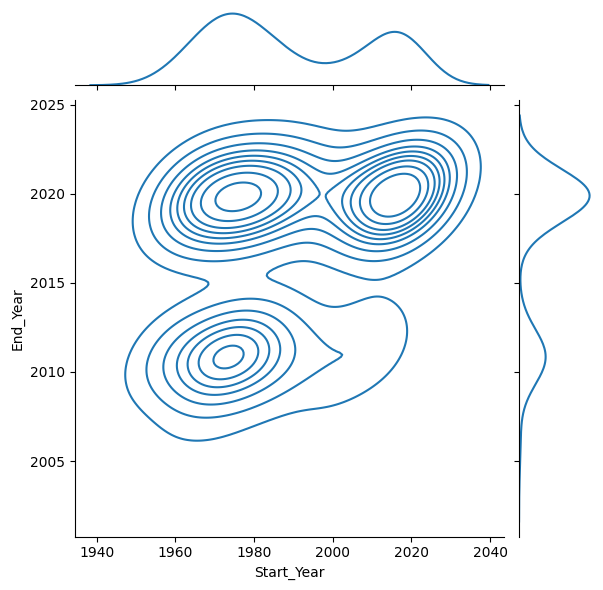

In [9]:
sns.jointplot(x='Start_Year', y='End_Year', data=df, kind='kde')

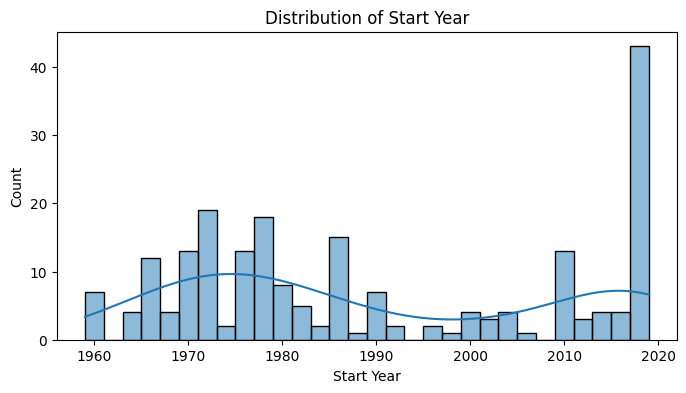

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Start_Year', kde=True, bins=30)
plt.title('Distribution of Start Year')
plt.xlabel('Start Year')
plt.ylabel('Count')
plt.show()

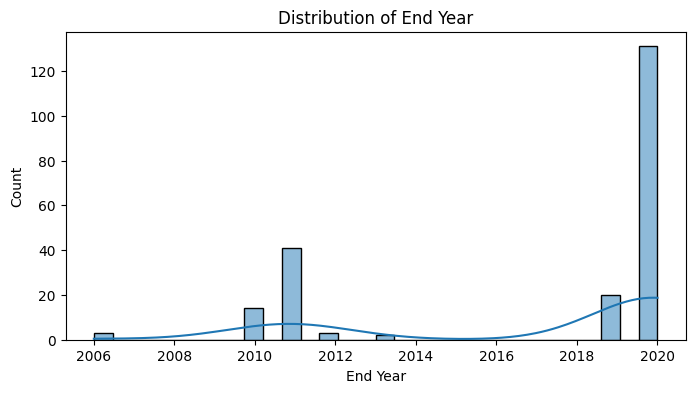

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='End_Year', kde=True, bins=30)
plt.title('Distribution of End Year')
plt.xlabel('End Year')
plt.ylabel('Count')
plt.show()

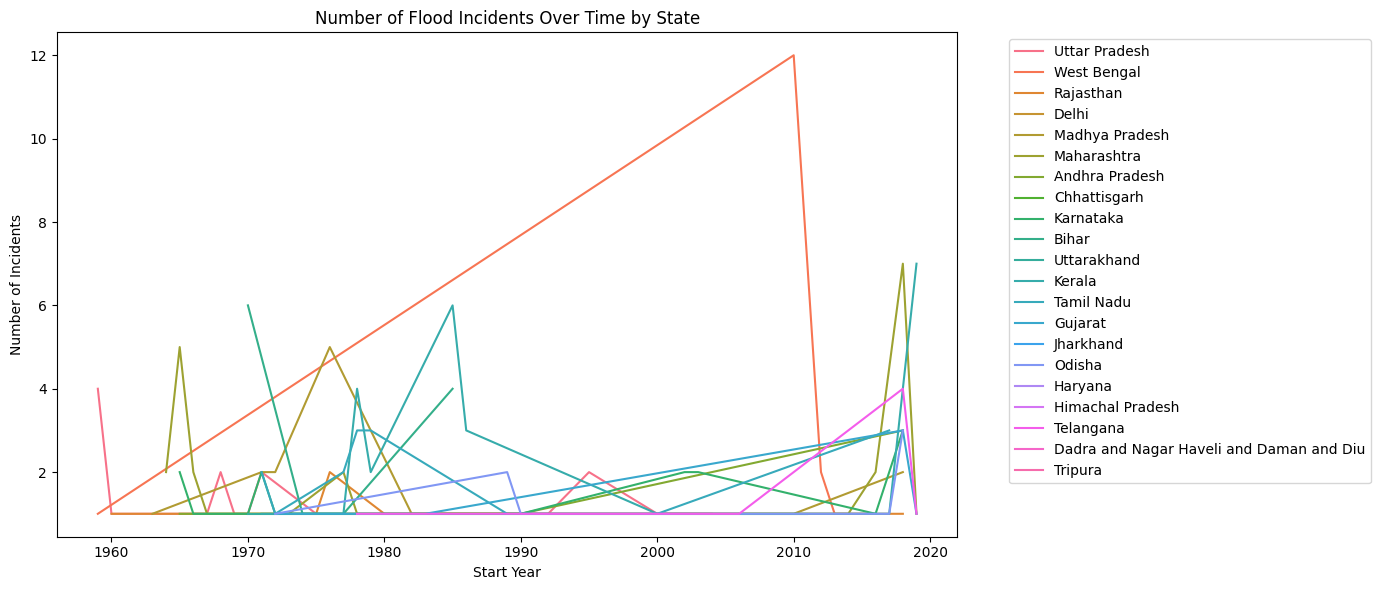

In [12]:
incidents_per_year_state = df.groupby(['Start_Year', 'State']).size().reset_index(name='Incident_Count')
incidents_per_year_state = incidents_per_year_state.sort_values('Start_Year')
plt.figure(figsize=(14, 6))
sns.lineplot(data=incidents_per_year_state, x='Start_Year', y='Incident_Count', hue='State')
plt.title('Number of Flood Incidents Over Time by State')
plt.xlabel('Start Year')
plt.ylabel('Number of Incidents')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

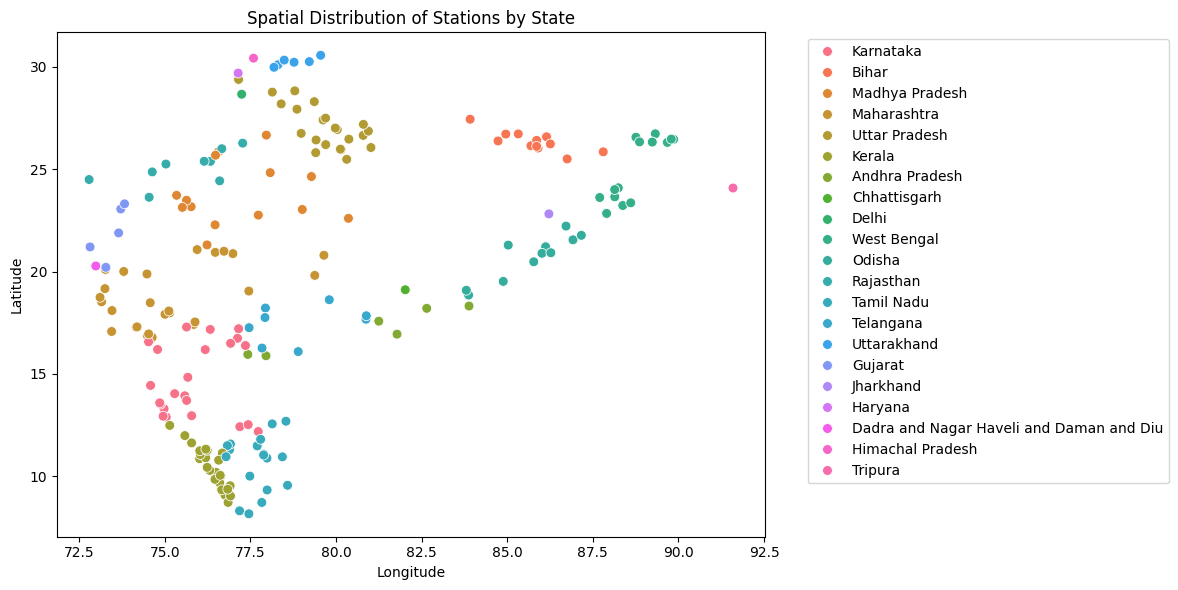

In [13]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='State', s=50)
plt.title('Spatial Distribution of Stations by State')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

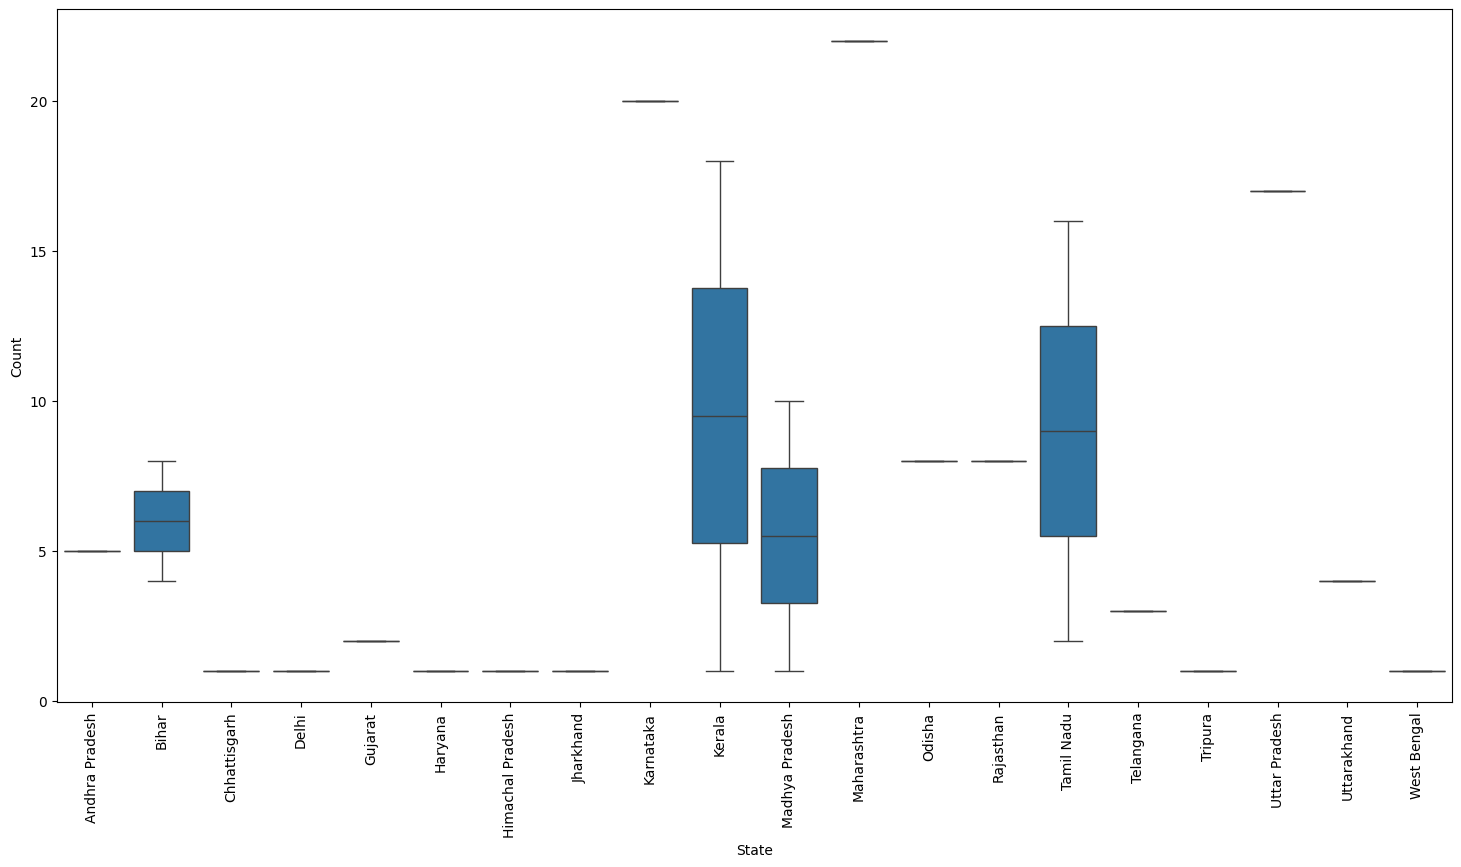

In [14]:
df['stream'] = df['Streamflow_Entries'] > 0
stream_counts = df[df['stream']].groupby(['State', 'Reliability']).size().reset_index(name='Count')
plt.figure(figsize = (18,9))
sns.boxplot(x='State', y='Count', data=stream_counts)
plt.xticks(rotation=90)
plt.show()

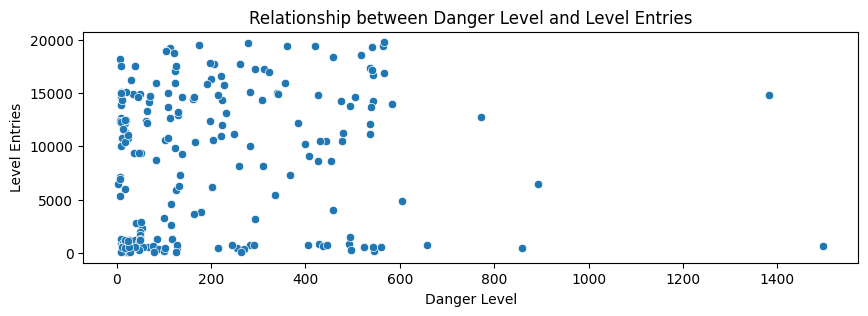

In [15]:
plt.figure(figsize=(10, 3))
sns.scatterplot(data=df, x='Danger Level', y='Level_Entries')
plt.title('Relationship between Danger Level and Level Entries')
plt.xlabel('Danger Level')
plt.ylabel('Level Entries')
plt.show()

In [16]:
plt.figure(figsize=(8, 4))
sns.barplot(x='Incident_Count', y='River Name', data=river_counts_up.head(10).sort_values('Incident_Count', ascending=False), color = 'teal')
plt.title('Distribution of Incident Counts for Top 10 Rivers (Ganga and Tributaries)', fontsize=16)
plt.xlabel('Incident Count', fontsize=12)
plt.ylabel('River Name', fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'river_counts_up' is not defined

<Figure size 800x400 with 0 Axes>

In [ ]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Incident_Count', y='State', data=state_counts.sort_values('Incident_Count', ascending=False), palette='viridis')
plt.title('Number of Flood Incidents per State', fontsize=16)
plt.xlabel('Number of Incidents', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
cols_to_plot = ["Level_Entries", "Streamflow_Entries", "Warning Level", "Danger Level", "Area variation (%)"]
sns.pairplot(df[cols_to_plot])



**Conclusion**
The dataset provides a comprehensive hydrological and geographical overview of Indian flood gauge stations along with metadata for improved flood event analysis. The presented code shows initial data loading, cleaning, and visualization steps supporting detailed flood risk studies.